In [ ]:
pip install torch torchvision matplotlib scikit-learn

cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 600kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.45MB/s]



Training ANN

Epoch 1/10 Loss=0.2493
Epoch 2/10 Loss=0.0986
Epoch 3/10 Loss=0.0705
Epoch 4/10 Loss=0.0561
Epoch 5/10 Loss=0.0427
Epoch 6/10 Loss=0.0371
Epoch 7/10 Loss=0.0335
Epoch 8/10 Loss=0.0284
Epoch 9/10 Loss=0.0235
Epoch 10/10 Loss=0.0245

Training CNN

Epoch 1/10 Loss=0.1332
Epoch 2/10 Loss=0.0426
Epoch 3/10 Loss=0.0298
Epoch 4/10 Loss=0.0219
Epoch 5/10 Loss=0.0173
Epoch 6/10 Loss=0.0123
Epoch 7/10 Loss=0.0109
Epoch 8/10 Loss=0.0090
Epoch 9/10 Loss=0.0079
Epoch 10/10 Loss=0.0071

RESULTS
ANN Accuracy : 97.86%
CNN Accuracy : 98.89%

ANN Training Time : 163.98 sec
CNN Training Time : 803.13 sec


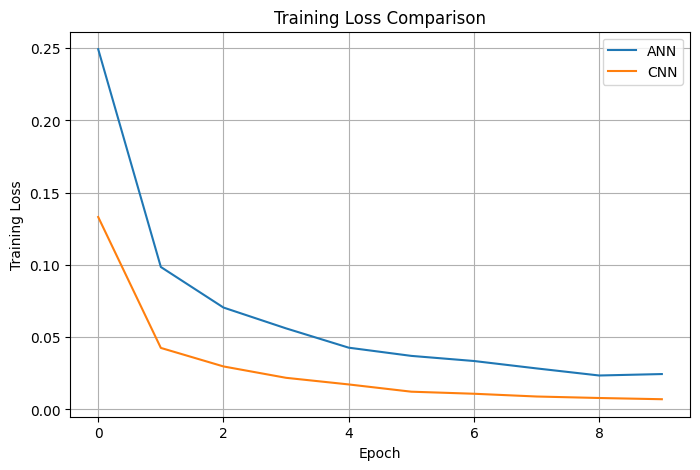

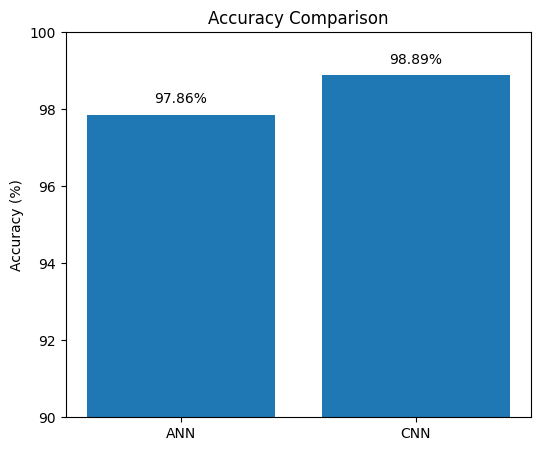

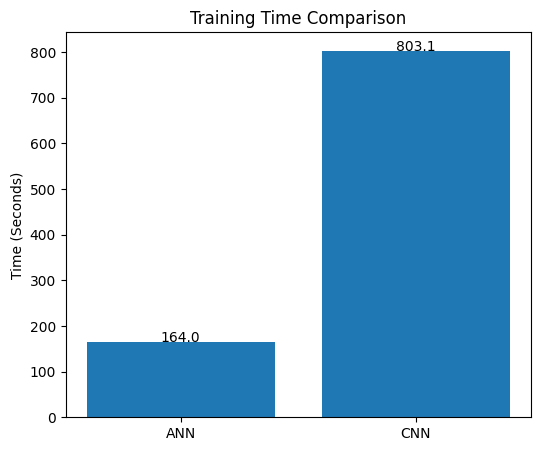

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

###############################################
# Hyperparameters
###############################################

batch_size = 64
learning_rate = 0.001
epochs = 10

###############################################
# MNIST Dataset
###############################################

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

###############################################################
# Simple Neural Network
###############################################################

class ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28*28,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,10)

        )

    def forward(self,x):
        return self.network(x)

###############################################################
# CNN
###############################################################

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)

        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*7*7,128),
            nn.ReLU(),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

###############################################################
# Training Function
###############################################################

def train_model(model):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(),
                           lr=learning_rate)

    model.to(device)

    losses=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()

        running_loss=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss/len(train_loader)

        losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} Loss={epoch_loss:.4f}")

    total_time=time.time()-start

    return losses,total_time

###############################################################
# Testing Function
###############################################################

def evaluate(model):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)

            correct+=(predicted==labels).sum().item()

    accuracy=100*correct/total

    return accuracy

###############################################################
# Train ANN
###############################################################

print("\nTraining ANN\n")

ann=ANN()

ann_loss,ann_time=train_model(ann)

ann_accuracy=evaluate(ann)

###############################################################
# Train CNN
###############################################################

print("\nTraining CNN\n")

cnn=CNN()

cnn_loss,cnn_time=train_model(cnn)

cnn_accuracy=evaluate(cnn)

###############################################################
# Results
###############################################################

print("\n=============================")
print("RESULTS")
print("=============================")

print(f"ANN Accuracy : {ann_accuracy:.2f}%")
print(f"CNN Accuracy : {cnn_accuracy:.2f}%")

print()

print(f"ANN Training Time : {ann_time:.2f} sec")
print(f"CNN Training Time : {cnn_time:.2f} sec")

###############################################################
# Plot Loss
###############################################################

plt.figure(figsize=(8,5))

plt.plot(ann_loss,label="ANN")

plt.plot(cnn_loss,label="CNN")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

###############################################################
# Accuracy Comparison
###############################################################

plt.figure(figsize=(6,5))

models=["ANN","CNN"]

accuracy=[ann_accuracy,cnn_accuracy]

bars=plt.bar(models,accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison")

for bar in bars:

    y=bar.get_height()

    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.3,
             f"{y:.2f}%",
             ha='center')

plt.ylim(90,100)

plt.show()

###############################################################
# Time Comparison
###############################################################

plt.figure(figsize=(6,5))

times=[ann_time,cnn_time]

bars=plt.bar(models,times)

plt.ylabel("Time (Seconds)")

plt.title("Training Time Comparison")

for bar in bars:

    y=bar.get_height()

    plt.text(bar.get_x()+bar.get_width()/2,
             y,
             f"{y:.1f}",
             ha='center')

plt.show()